In [1]:
# import packages
%matplotlib inline

import os
import sys
from multiprocessing import Process, Queue
import pandas as pd
import optuna
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from dataclasses import dataclass
sys.path.append('~/src/GSASII/GSASII/')

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [7]:
# ====== テストデータへのリンク ======
import os
from pathlib import Path

TUTDIR = "~/src/GSASII/GSAS-II-tutorials/TOF-CW Joint Refinement/data"
WORKDIR = "work_tof/tutorial_GSASII/NAC_BBO"


Path(WORKDIR).mkdir(parents=True, exist_ok=True)
Path("%s/cycle"%(WORKDIR)).mkdir(parents=True, exist_ok=True)

# CIF
src = Path("%s/NAC.cif"%(TUTDIR)).expanduser()
dst = Path("%s/NAC.cif"%(WORKDIR)).expanduser()
dst.unlink(missing_ok=True)
dst.symlink_to(src)


# TOF powder data
src = Path("%s/PG3_22048.gsa"%(TUTDIR)).expanduser()
dst = Path("%s/PG3_22048.gsa"%(WORKDIR)).expanduser()
dst.unlink(missing_ok=True)
dst.symlink_to(src)


# TOF instrument parameter
src = Path("%s/POWGEN_1066.instprm"%(TUTDIR)).expanduser()
dst = Path("%s/POWGEN_1066.instprm"%(WORKDIR)).expanduser()
dst.unlink(missing_ok=True)
dst.symlink_to(src)

In [8]:
# Configurations

### Change here ###
STUDY_NAME = 'NAC'
RANDOM_SEED = 1024

DATA_DIR = WORKDIR
# all output files include GSAS project file (*.gpx) will be saved in WORK_DIR
WORK_DIR = WORKDIR + '/cycle'

In [9]:
# make directories
! rm -f $WORK_DIR/$STUDY_NAME*
! mkdir -p $WORK_DIR

zsh:1: no matches found: work_tof/tutorial_GSASII/NAC_BBO/cycle/NAC*


In [10]:
@dataclass
class ProjectConfig:
    work_dir: str
    random_seed: int
    data_dir: str
    cif_file: str
    csv_file: str
    prm_file: str

In [21]:
class Project:
    def __init__(self, config, trial_number):
        import os
        import GSASIIscriptable as G2sc

        self.gpx = G2sc.G2Project(
            newgpx=os.path.join(
                config.work_dir,
                f'{STUDY_NAME}_seed{config.random_seed}_trial_{trial_number}.gpx'
            )
        )

        self.hist1 = self.gpx.add_powder_histogram(
            os.path.join(config.data_dir, config.csv_file),
            os.path.join(config.data_dir, config.prm_file)
        )

        self.phase0 = self.gpx.add_phase(
            os.path.join(config.data_dir, config.cif_file),
            phasename=config.cif_file.split(".cif")[0],
            histograms=[self.hist1]
        )

        # isotropic U
        for atom in self.phase0.data['Atoms']:
            atom[9] = 'I'

    def refine_and_calc_Rwp(self, param_dict):
        self.gpx.do_refinements([param_dict])
        return self.hist1.get_wR()

    def fix_inst_params(self, keys=None):
        if keys is None:
            keys = [
                'Zero', 'difC',
                'alpha', 'beta-0', 'beta-1', 'beta-q'
            ]

        inst = self.hist1.data["Instrument Parameters"][0]

        for key in keys:
            if key in inst and len(inst[key]) >= 3:
                inst[key][2] = False

    def fix_cells(self):
        self.phase0.set_refinements({"Cell": False})

    def fix_background(self):
        self.hist1.set_refinements({"Background": False})

    def fix_scale(self):
        self.hist1.data["Sample Parameters"]["Scale"][1] = False

    def fix_params(self, flag):
        if flag is None:
            return

        if flag == 'Instrument Parameters':
            self.fix_inst_params()
        elif flag == 'Cell':
            self.fix_cells()
        elif flag == 'Background':
            self.fix_background()
        elif flag == 'Scale':
            self.fix_scale()
        else:
            raise ValueError(f"Unknown flag: {flag}")

In [22]:
# Example usage:
config = ProjectConfig(
    work_dir=WORK_DIR,
    random_seed=RANDOM_SEED,
    data_dir=DATA_DIR,
    cif_file='NAC.cif',
    #csv_file='NAC.csv',
    csv_file='PG3_22048.gsa',
    prm_file='POWGEN_1066.instprm'
)

In [23]:
def objective(trial, config):
    import sys

    ERROR_PENALTY = 1e9

    try:
        # -------------------------
        # Search space
        # -------------------------

        # Limits
        limits_lb = trial.suggest_float(
            'Limits lower bound',
            11500.0,
            12500.0
        )
        limits_ub = trial.suggest_float(
            'Limits upper bound',
            95000.0,
            105000.0
        )
        limits_refine = trial.suggest_categorical(
            'limits refine',
            [True, False]
        )

        refdict_limits = {
            'set': {
                'Limits': [limits_lb, limits_ub]
            },
            'refine': limits_refine
        }

        # Background
        no_coeffs = 1
        background_refine = trial.suggest_categorical(
            'Background refine',
            [True, False]
        )

        refdict_background = {
            'set': {
                'Background': {
                    'type': 'chebyschev-1',
                    'no. coeffs': no_coeffs,
                    'refine': background_refine
                }
            }
        }

        # Instrument parameters: refine only once
        instrument_parameters_refine = []

        for p in ['Zero', 'difC']:
            if trial.suggest_categorical(
                f'Instrument_parameters refine {p}',
                [True, False]
            ):
                instrument_parameters_refine.append(p)

        for p in ['alpha', 'beta-0', 'beta-1', 'beta-q']:
            if trial.suggest_categorical(
                f'Peakshape_parameters refine {p}',
                [True, False]
            ):
                instrument_parameters_refine.append(p)

        cell_refine = trial.suggest_categorical(
            'cell refine',
            [True, False]
        )

        refdict_cell_and_inst_once = {
            'set': {
                'Cell': cell_refine,
                'Instrument Parameters': instrument_parameters_refine
            }
        }

        # Fix instrument parameters after one refinement
        refdict_fix_inst = {
            'clear': {
                'Instrument Parameters': [
                    'Zero', 'difC',
                    'alpha', 'beta-0', 'beta-1', 'beta-q'
                ]
            }
        }

        # Scale
        sample_parameters_refine = []

        for p in ['Scale']:
            if trial.suggest_categorical(
                f'Sample_parameters refine {p}',
                [True, False]
            ):
                sample_parameters_refine.append(p)

        refdict_scale = {
            'set': {
                'Sample Parameters': sample_parameters_refine
            }
        }

        # Atomic positions
        refdict_atoms_xyz = {
            'set': {
                'Atoms': {
                    'all': 'X'
                }
            }
        }

        # Atomic displacement parameters
        refdict_atoms_u = {
            'set': {
                'Atoms': {
                    'all': 'U'
                }
            }
        }

        # Final refinement
        # Instrument Parameters はここに入れない
        refdict_final = {
            'set': {
                'Limits': [12000.0, 100000.0],
                'Background': {
                    'type': 'chebyschev-1',
                    'no. coeffs': no_coeffs,
                    'refine': True
                },
                'Cell': True,
                'Sample Parameters': ['Scale'],
                'Atoms': {
                    'all': 'XU'
                }
            },
            'refine': True
        }

        refine_params_list = [
            refdict_limits,
            refdict_background,
            refdict_cell_and_inst_once,
            refdict_fix_inst,
            refdict_scale,
            refdict_atoms_xyz,
            refdict_atoms_u,
            refdict_final
        ]

        # -------------------------
        # Evaluate
        # -------------------------

        project = Project(config, trial.number)

        for params in refine_params_list:
            Rwp = project.refine_and_calc_Rwp(params)

        # 念のため、直接内部フラグもOFFにしておく
        project.fix_inst_params()

        # validate Uiso >= 0
        phase_main = project.gpx.phases()[0]
        u_iso_list = [atom.uiso for atom in phase_main.atoms()]

        if min(u_iso_list) < 0:
            return ERROR_PENALTY

        return Rwp

    except Exception as e:
        print(e, file=sys.stderr)
        return ERROR_PENALTY

In [24]:
# Create Optuna study
study = optuna.create_study(study_name=STUDY_NAME + '_seed%s' % (RANDOM_SEED),
                            storage=f"sqlite:///{config.work_dir}/history_sqlite.db", 
                            load_if_exists=True,
                            sampler=optuna.samplers.TPESampler(n_startup_trials=20, seed=RANDOM_SEED))

[I 2026-06-17 09:04:57,257] A new study created in RDB with name: NAC_seed1024


Run 200 refinements to find the best configuration. It may take abount an hour to complete.

In [25]:
# Optimize
#study.optimize(objective, n_trials=200, n_jobs=1)
#study.optimize(func=lambda trial: objective(trial, config), n_trials=100)
study.optimize(func=lambda trial: objective(trial, config), n_trials=10)

/Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC_BBO/PG3_22048.gsa read by Reader GSAS powder data
Instrument parameters read: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC_BBO/POWGEN_1066.instprm (G2 fmt) bank 2
Keyed packet: ['Ca1', '0.0083', '0.0096', '0.0080', '0.0000', '0.0000', '-0.0000']
Keyed packet: ['Al1', '0.0078', '0.0078', '0.0078', '-0.0007', '-0.0007', '-0.0007']
Keyed packet: ['Na1', '0.0255', '0.0255', '0.0255', '-0.0074', '-0.0074', '-0.0074']
Keyed packet: ['F1', '0.0102', '0.0110', '0.0128', '0.0006', '-0.0018', '0.0020']
Keyed packet: ['F2', '0.0115', '0.0158', '0.0124', '-0.0071', '0.0007', '0.0024']
Keyed packet: ['F3', '0.0095', '0.0095', '0.0095', '0.0007', '0.0007', '0.0007']
/Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC_BBO/NAC.cif read by Reader CIF
gpx file saved as /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC_BBO/cycle/NAC_seed1024_trial_0.gpx
gpx file saved as /Users/tsuneto

[I 2026-06-17 09:05:36,707] Trial 0 finished with value: 1000000000.0 and parameters: {'Limits lower bound': 12147.691230661978, 'Limits upper bound': 104969.13579872574, 'limits refine': False, 'Background refine': False, 'Instrument_parameters refine Zero': True, 'Instrument_parameters refine difC': False, 'Peakshape_parameters refine alpha': False, 'Peakshape_parameters refine beta-0': True, 'Peakshape_parameters refine beta-1': True, 'Peakshape_parameters refine beta-q': True, 'cell refine': True, 'Sample_parameters refine Scale': True}. Best is trial 0 with value: 1000000000.0.


Read from file: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC_BBO/cycle/NAC_seed1024_trial_0.bak0.gpx
Save to file: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC_BBO/cycle/NAC_seed1024_trial_0.gpx
GPX file save successful
 Refinement results are in file: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC_BBO/cycle/NAC_seed1024_trial_0.lst
 ***** Refinement successful *****
/Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC_BBO/PG3_22048.gsa read by Reader GSAS powder data
Instrument parameters read: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC_BBO/POWGEN_1066.instprm (G2 fmt) bank 2
Keyed packet: ['Ca1', '0.0083', '0.0096', '0.0080', '0.0000', '0.0000', '-0.0000']
Keyed packet: ['Al1', '0.0078', '0.0078', '0.0078', '-0.0007', '-0.0007', '-0.0007']
Keyed packet: ['Na1', '0.0255', '0.0255', '0.0255', '-0.0074', '-0.0074', '-0.0074']
Keyed packet: ['F1', '0.0102', '0.0110', '0.0128', '0.0006', 

/Users/tsunetomo/.pyenv/versions/miniforge3-4.14.0-2/envs/powder/lib/python3.13/site-packages/GSASII/GSASIIstrMath.py:5011: RuntimeWarning: invalid value encountered in scalar divide
  Histogram['Residuals']['Rb'] = min(100.,100.*sumYB/sumYmB)
/Users/tsunetomo/.pyenv/versions/miniforge3-4.14.0-2/envs/powder/lib/python3.13/site-packages/GSASII/GSASIIstrMath.py:5012: RuntimeWarning: invalid value encountered in scalar divide
  Histogram['Residuals']['wRb'] = min(100.,100.*ma.sqrt(sumwYB2/sumwYmB2))


divergence: chi^2 6.5119e+06 on 5303 obs. (0 SVD zeros)
	increasing Marquardt lambda to 1.0e+01
Cycle 0: 2.74s, Chi**2: 5.7648e+06 for 5303 obs., Lambda: 10,  Delta: 0.0398, SVD=0
Cycle 1: 0.83s, Chi**2: 5.1525e+06 for 5303 obs., Lambda: 10,  Delta: 0.106, SVD=0
Cycle 2: 0.82s, Chi**2: 5.1314e+06 for 5303 obs., Lambda: 10,  Delta: 0.00408, SVD=0
Maximum shift/esd = 9.010 for all cycles
Read from file: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC_BBO/cycle/NAC_seed1024_trial_1.bak0.gpx
Save to file: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC_BBO/cycle/NAC_seed1024_trial_1.gpx
GPX file save successful
 Refinement results are in file: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC_BBO/cycle/NAC_seed1024_trial_1.lst
 ***** Refinement successful *****
gpx file saved as /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC_BBO/cycle/NAC_seed1024_trial_1.gpx
 Hessian Levenberg-Marquardt SVD refinement on 2 variable

...

ouch #2 bad SVD inversion; dropping terms for for variable(s) #[np.int64(0)]
ouch #2 bad SVD inversion; dropping terms for for variable(s) #[np.int64(0)]
ouch #2 bad SVD inversion; dropping terms for for variable(s) #[np.int64(0)]
giving up with ouch #2
****ERROR - Refinement failed
Note refinement problem:
SVD inversion failure

 ***** Refinement error *****
Note refinement problem:
SVD inversion failure


**** ERROR: Refinement failed ****
gpx file saved as /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC_BBO/cycle/NAC_seed1024_trial_8.gpx
 Hessian Levenberg-Marquardt SVD refinement on 19 variables:
initial chi^2 7.0544e+05 with 5302 obs.
Cycle 0: 0.42s, Chi**2: 4.0545e+05 for 5302 obs., Lambda: 0,  Delta: 0.425, SVD=0
Cycle 1: 0.42s, Chi**2: 3.5951e+05 for 5302 obs., Lambda: 0,  Delta: 0.113, SVD=0
Cycle 2: 0.41s, Chi**2: 3.5099e+05 for 5302 obs., Lambda: 0,  Delta: 0.0237, SVD=0
Maximum shift/esd = 32.561 for all cycles
Read from file: /Users/tsunetomo/dev/BBO-Rie

[I 2026-06-17 09:08:39,208] Trial 8 finished with value: 1000000000.0 and parameters: {'Limits lower bound': 11510.259157497676, 'Limits upper bound': 98306.23129482243, 'limits refine': False, 'Background refine': True, 'Instrument_parameters refine Zero': False, 'Instrument_parameters refine difC': False, 'Peakshape_parameters refine alpha': True, 'Peakshape_parameters refine beta-0': True, 'Peakshape_parameters refine beta-1': False, 'Peakshape_parameters refine beta-q': True, 'cell refine': False, 'Sample_parameters refine Scale': True}. Best is trial 2 with value: 100.0.


GPX file save successful
 Refinement results are in file: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC_BBO/cycle/NAC_seed1024_trial_8.lst
 ***** Refinement successful *****
/Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC_BBO/PG3_22048.gsa read by Reader GSAS powder data
Instrument parameters read: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC_BBO/POWGEN_1066.instprm (G2 fmt) bank 2
Keyed packet: ['Ca1', '0.0083', '0.0096', '0.0080', '0.0000', '0.0000', '-0.0000']
Keyed packet: ['Al1', '0.0078', '0.0078', '0.0078', '-0.0007', '-0.0007', '-0.0007']
Keyed packet: ['Na1', '0.0255', '0.0255', '0.0255', '-0.0074', '-0.0074', '-0.0074']
Keyed packet: ['F1', '0.0102', '0.0110', '0.0128', '0.0006', '-0.0018', '0.0020']
Keyed packet: ['F2', '0.0115', '0.0158', '0.0124', '-0.0071', '0.0007', '0.0024']
Keyed packet: ['F3', '0.0095', '0.0095', '0.0095', '0.0007', '0.0007', '0.0007']
/Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial

[I 2026-06-17 09:08:56,944] Trial 9 finished with value: 1000000000.0 and parameters: {'Limits lower bound': 12386.365116569663, 'Limits upper bound': 100740.52975257079, 'limits refine': False, 'Background refine': True, 'Instrument_parameters refine Zero': False, 'Instrument_parameters refine difC': False, 'Peakshape_parameters refine alpha': False, 'Peakshape_parameters refine beta-0': True, 'Peakshape_parameters refine beta-1': False, 'Peakshape_parameters refine beta-q': True, 'cell refine': True, 'Sample_parameters refine Scale': False}. Best is trial 2 with value: 100.0.


Read from file: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC_BBO/cycle/NAC_seed1024_trial_9.bak0.gpx
Save to file: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC_BBO/cycle/NAC_seed1024_trial_9.gpx
GPX file save successful
 Refinement results are in file: /Users/tsunetomo/dev/BBO-Rietveld-TOF/work_tof/tutorial_GSASII/NAC_BBO/cycle/NAC_seed1024_trial_9.lst
 ***** Refinement successful *****


In [38]:
df = study.trials_dataframe()
df.rename(columns={'value': 'Rwp', 'number': 'trial'}, inplace=True)
df.columns = [
    c.replace('params_', '') if c.startswith('params_') else c
    for c in df.columns
]

df.drop(
    columns=['state', 'datetime_start', 'datetime_complete', 'duration'],
    inplace=True,
    rrors='ignore'
)

df = df.sort_values('Rwp')

TypeError: DataFrame.drop() got an unexpected keyword argument 'rrors'. Did you mean 'errors'?

In [34]:
# Best configuration
study.best_params

{'Limits lower bound': 11769.28007422069,
 'Limits upper bound': 103720.61546133546,
 'limits refine': False,
 'Background refine': True,
 'Instrument_parameters refine Zero': False,
 'Instrument_parameters refine difC': True,
 'Peakshape_parameters refine alpha': True,
 'Peakshape_parameters refine beta-0': False,
 'Peakshape_parameters refine beta-1': True,
 'Peakshape_parameters refine beta-q': False,
 'cell refine': False,
 'Sample_parameters refine Scale': True}

In [35]:
# Best Rwp
study.best_value

100.0

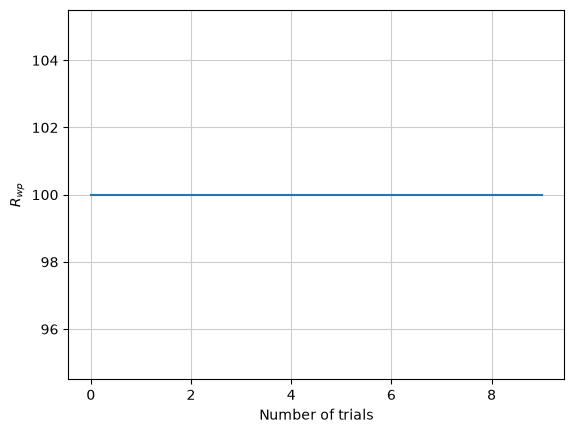

In [36]:
# Rwp plot
def rwp_plot():
    minvalues = [df.iloc[0]['Rwp']]
    for i in range(1, df.shape[0]):
        minvalues.append(min(minvalues[-1], df.iloc[i]['Rwp']))
    minvalues = pd.DataFrame(minvalues)
    
    minvalues.plot(legend=None)
#     plt.ylim([6, 16])
    plt.grid(color='#cccccc')
    plt.ylabel('$R_{wp}$')
    plt.xlabel('Number of trials')
    plt.show()
    
rwp_plot()

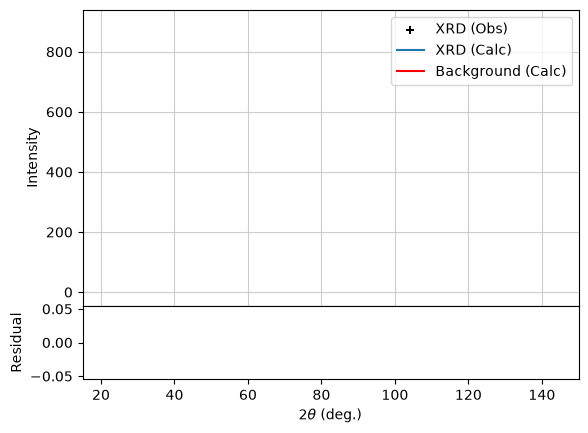

In [37]:
# Rietveld plot
def rietveld_plot():
    import GSASIIscriptable as G2sc

    gpx = G2sc.G2Project(
        '%s/%s_seed%s_trial_%s.gpx' % (WORK_DIR, STUDY_NAME, RANDOM_SEED, study.best_trial.number))

    hist1 = gpx.histograms()[0]
    phase0 = gpx.phases()[0]

    hist = hist1
    i = 5
    two_theta = hist.getdata("X")[::i]
    Yobs = hist.getdata("Yobs")[::i]
    Ycalc = hist.getdata("Ycalc")[::i]
    bg = hist.getdata("Background")[::i]
    residual = hist.getdata("Residual")[::i]

    fig = plt.figure()
    gs = GridSpec(5, 1, figure=fig)
    ax1 = fig.add_subplot(gs[:4, :])
    ax2 = fig.add_subplot(gs[4, :])
    fig.subplots_adjust(hspace=0)
    ax1.grid(color='#cccccc')

    ax1.scatter(two_theta, Yobs, marker='P', lw=0.0001, c='Black', label='XRD (Obs)')
    ax1.plot(two_theta, Ycalc, label='XRD (Calc)')
    ax1.plot(two_theta, bg, color='red', label='Background (Calc)')
    ax1.set_ylabel('Intensity')
    ax1.legend()
    ax2.plot(two_theta, residual, color='blue')
    plt.setp(ax1.get_xticklabels(), visible=False);
    # ax2.set_ylim(-6600, 6600)
    plt.xlabel(r'$2\theta$ (deg.)')
    ax2.set_ylabel('Residual')
    # change 2theta range according to your data
    ax1.set_xlim(15, 150)
    ax2.set_xlim(15, 150)
    plt.show()
    
rietveld_plot()